### 导入数据集

In [460]:
import numpy as np
import matplotlib.pyplot as plt

In [461]:
np.random.seed(233)
x = np.random.uniform(-4, 2, size=100)
y = x ** 2 + 4 * x + 3 + 2 * np.random.randn(100)
X = x.reshape(-1, 1)

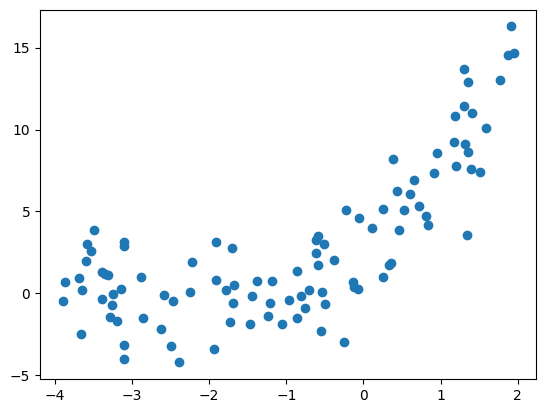

In [462]:
plt.scatter(x, y)
plt.show()

### 欠拟合

In [463]:
from sklearn.linear_model import LinearRegression

In [464]:
linear_regression = LinearRegression()
linear_regression.fit(X, y);

In [465]:
y_predict = linear_regression.predict(X)

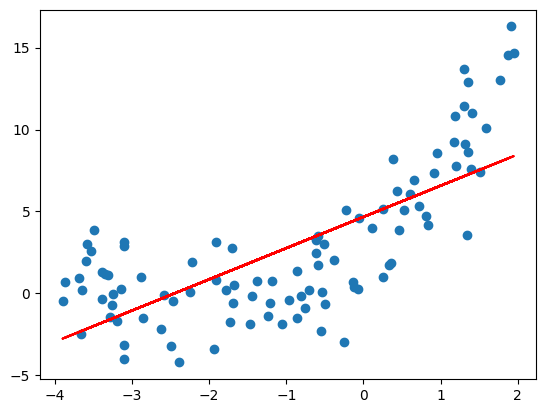

In [466]:
plt.scatter(x, y)
plt.plot(x, y_predict, 'r')
plt.show()

In [467]:
linear_regression.score(X, y)

0.5273556058762796

### 过拟合

In [468]:
from sklearn.preprocessing import PolynomialFeatures

In [469]:
polynomial_features = PolynomialFeatures(degree=2)
X_poly = polynomial_features.fit_transform(X)

In [470]:
linear_regression = LinearRegression()
linear_regression.fit(X_poly, y);

In [471]:
y_predict = linear_regression.predict(X_poly)

In [472]:
linear_regression.score(X_poly, y)

0.7961121480231473

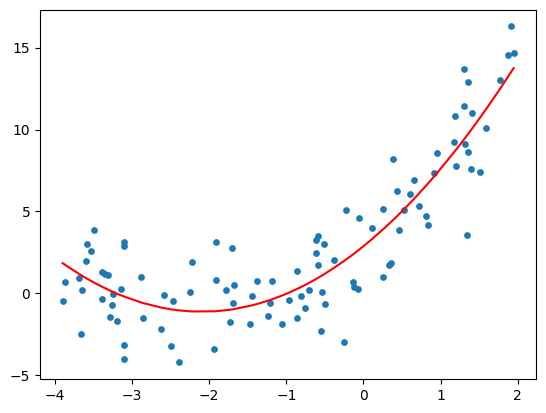

In [473]:
plt.scatter(x, y, s=15)
plt.plot(np.sort(x), y_predict[np.argsort(x)], 'r')
plt.show()

In [474]:
X_new = np.linspace(-5, 5, 100).reshape(-1, 1)
X_new_poly = polynomial_features.fit_transform(X_new)
y_predict = linear_regression.predict(X_new_poly)

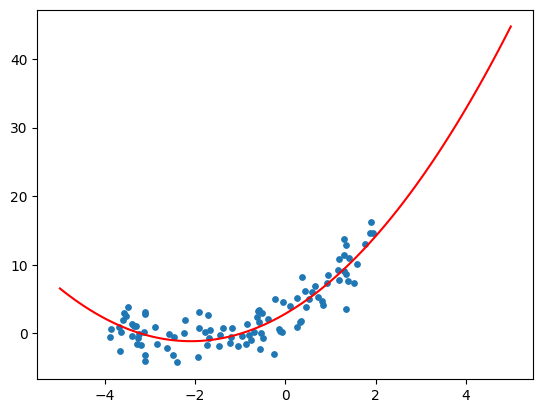

In [475]:
plt.scatter(x, y, s=15)
plt.plot(X_new, y_predict, 'r')
plt.show()

In [476]:
linear_regression.score(X_poly, y)

0.7961121480231473

Degree: 2 Score: 0.7961121480231473
Degree: 5 Score: 0.8021247301740011
Degree: 10 Score: 0.8127498981127338
Degree: 15 Score: 0.41710145972443746
Degree: 20 Score: 0.1499917289794862
Degree: 24 Score: 0.10163599771931031


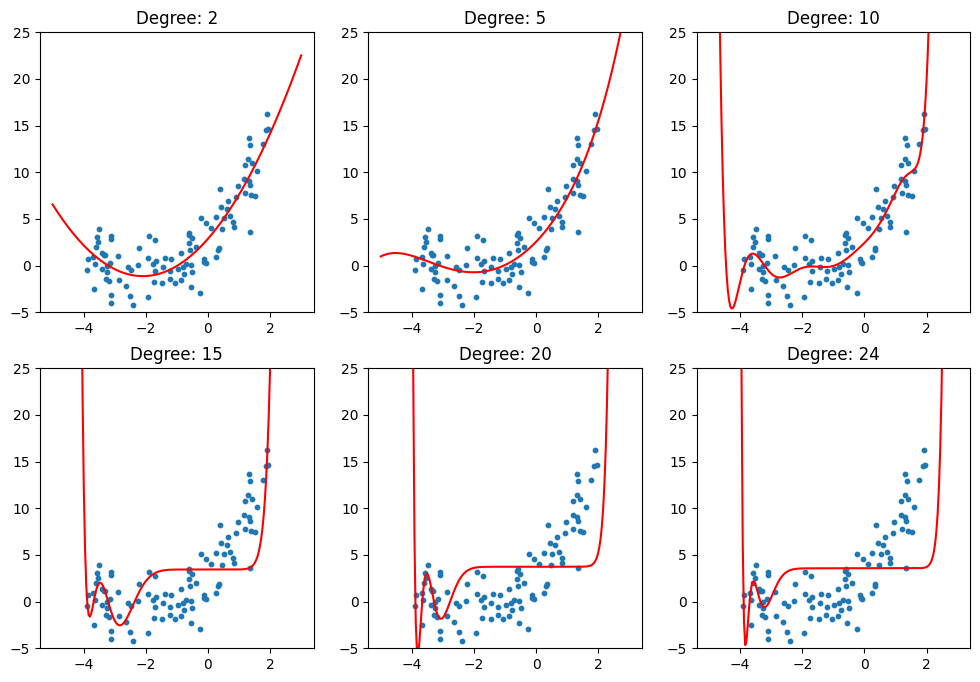

In [477]:
plt.figure(figsize=(12, 8))  # 设置当前图形大小
degrees = [2, 5, 10, 15, 20, 24]  # 设置不同的多项式次数
for i, degree in enumerate(degrees):  # 分别训练并绘制不同次数的多项式回归模型
    polynomial_features = PolynomialFeatures(degree=degree)  # 生成多项式特征
    X_poly = polynomial_features.fit_transform(X)

    linear_regression = LinearRegression()  # 训练线性回归模型
    linear_regression.fit(X_poly, y)

    X_new = np.linspace(-5, 3, 200).reshape(-1, 1)  # 生成用于绘制回归曲线的新数据
    X_new_poly = polynomial_features.fit_transform(X_new)
    y_predict = linear_regression.predict(X_new_poly)

    plt.subplot(2, 3, i + 1)  # 创建子图
    plt.title("Degree: {0}".format(degree))
    plt.scatter(x, y, s=10)  # 绘制原始数据和预测曲线
    plt.ylim(-5, 25)
    plt.plot(X_new, y_predict, color="red")

    print("Degree:", degree, "Score:", linear_regression.score(X_poly, y))  # 输出模型的 R² 得分
plt.show()